# Tesla Deliveries and Production Data Analysis (2015–2025)

## Objective

The objective of this project is to build an end-to-end Machine Learning pipeline using Tesla deliveries and production data.

This project covers:

- Data Loading
- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling (Price Prediction)
- Cross Validation
- Hyperparameter Tuning
- Time Series Analysis and Forecasting
- Model Evaluation

The goal is to predict Tesla vehicle average price and forecast future deliveries using historical sales and production data.

**Submitted by:** Ayush Choudhary  
**Internship:** Celebal Technologies  
**Week:** 2

## Importing Libraries

We import all required libraries for data manipulation, visualization, machine learning, and time series analysis.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("All libraries loaded successfully")

All libraries loaded successfully


## Data Loading and Dataset Overview

In this section, we load the Tesla deliveries dataset and perform an initial inspection to understand its structure, features, and overall quality.

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Dataset Loaded Successfully")
print("\nShape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset Loaded Successfully

Shape of Dataset:
(2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [3]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Data Cleaning

Before building machine learning models, we check for missing values and duplicate records that may affect model performance.

In [6]:
print("Missing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows:
0


The dataset has no missing values and no duplicate rows, so no imputation or deduplication is required.

We encode the `Source_Type` column as an ordinal reliability score since it represents data quality — Official data is more reliable than Interpolated, which is more reliable than Estimated.

In [7]:
print("Source_Type value counts:")
print(df["Source_Type"].value_counts())

reliability_map = {
    "Official (Quarter)": 3,
    "Interpolated (Month)": 2,
    "Estimated (Region)": 1
}

df["Source_Reliability"] = df["Source_Type"].map(reliability_map)

print("\nSource_Reliability column created successfully")

Source_Type value counts:
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64

Source_Reliability column created successfully


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand trends, relationships, and patterns within Tesla's deliveries and production data.

In this section, we visualize:

- Deliveries by Vehicle Model
- Deliveries by Region
- Yearly Delivery Trends
- Average Price Distribution
- Correlation Between Numerical Features
- Monthly Seasonality
- CO2 Savings Over Time

**EDA 1 — Total Deliveries by Model**

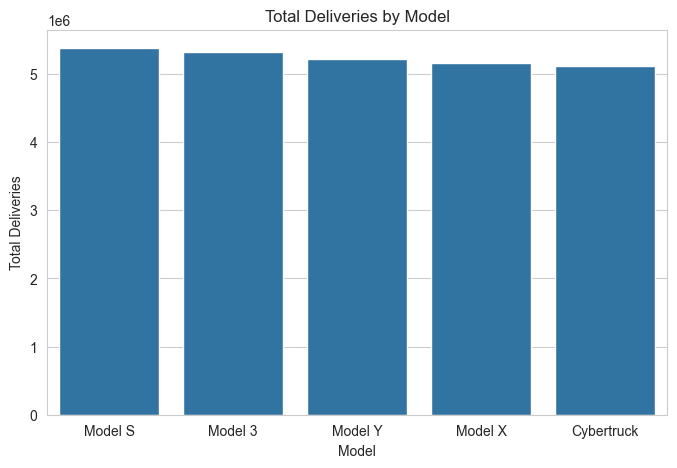

In [8]:
model_deliveries = (
    df.groupby("Model")["Estimated_Deliveries"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=model_deliveries.index,
    y=model_deliveries.values
)

plt.title("Total Deliveries by Model")

plt.xlabel("Model")

plt.ylabel("Total Deliveries")

plt.show()

**EDA 2 — Average Deliveries by Region**

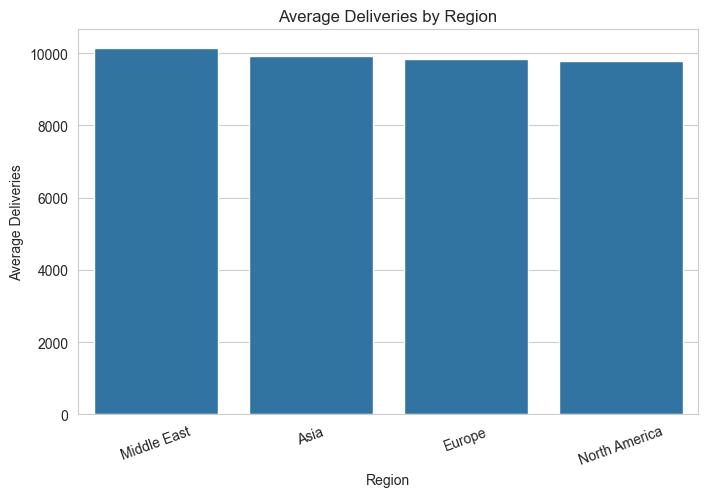

In [9]:
region_deliveries = (
    df.groupby("Region")["Estimated_Deliveries"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_deliveries.index,
    y=region_deliveries.values
)

plt.title("Average Deliveries by Region")

plt.xlabel("Region")

plt.ylabel("Average Deliveries")

plt.xticks(rotation=20)

plt.show()

**EDA 3 — Yearly Total Deliveries Trend**

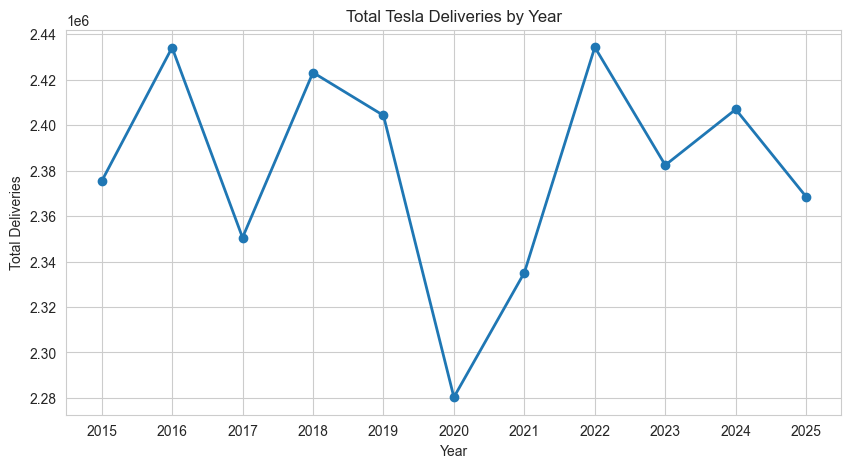

In [10]:
yearly = df.groupby("Year")["Estimated_Deliveries"].sum().reset_index()

plt.figure(figsize=(10, 5))

plt.plot(
    yearly["Year"],
    yearly["Estimated_Deliveries"],
    marker="o",
    linewidth=2
)

plt.title("Total Tesla Deliveries by Year")

plt.xlabel("Year")

plt.ylabel("Total Deliveries")

plt.xticks(yearly["Year"])

plt.show()

**EDA 4 — Average Price Distribution**

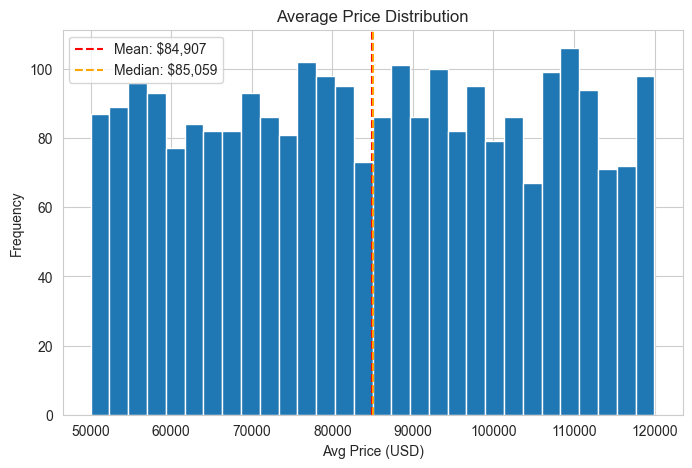

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(df["Avg_Price_USD"], bins=30, edgecolor="white")

plt.axvline(df["Avg_Price_USD"].mean(), color="red", linestyle="--", label=f'Mean: ${df["Avg_Price_USD"].mean():,.0f}')

plt.axvline(df["Avg_Price_USD"].median(), color="orange", linestyle="--", label=f'Median: ${df["Avg_Price_USD"].median():,.0f}')

plt.title("Average Price Distribution")

plt.xlabel("Avg Price (USD)")

plt.ylabel("Frequency")

plt.legend()

plt.show()

**EDA 5 — Correlation Heatmap**

We look at the correlation between all numerical features to understand which variables are related to each other.

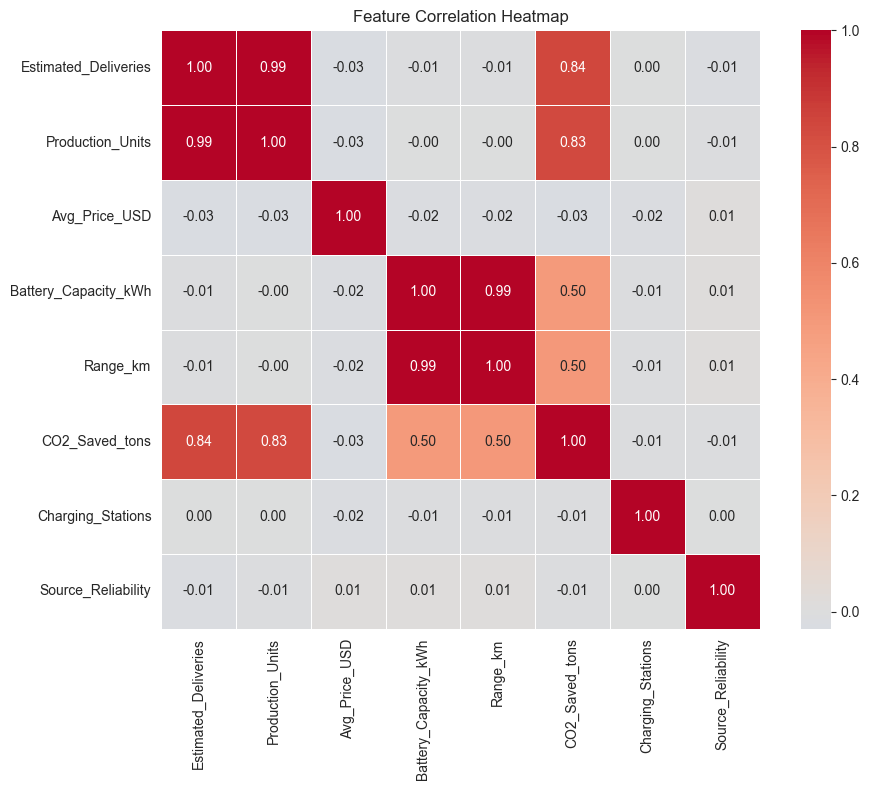

In [12]:
numeric_cols = [
    "Estimated_Deliveries",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
    "Source_Reliability"
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.show()

**EDA 6 — Monthly Seasonality**

We examine average deliveries per month to identify any seasonal patterns in Tesla's delivery schedule.

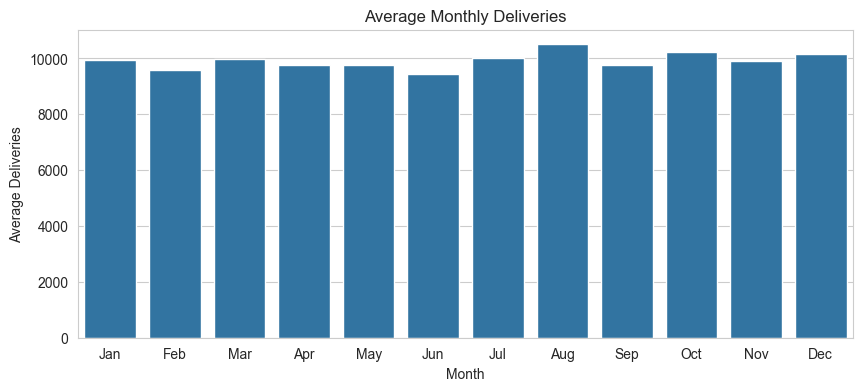

In [13]:
monthly_avg = df.groupby("Month")["Estimated_Deliveries"].mean()

month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(10, 4))

sns.barplot(
    x=month_names,
    y=monthly_avg.values
)

plt.title("Average Monthly Deliveries")

plt.xlabel("Month")

plt.ylabel("Average Deliveries")

plt.show()

**EDA 7 — CO2 Savings Over Years**

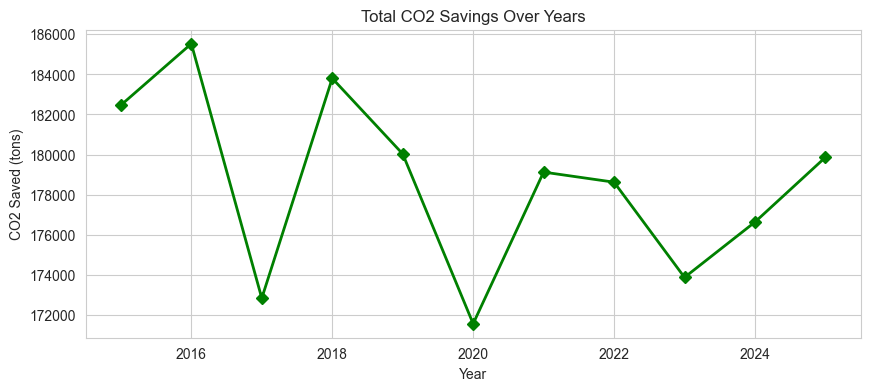

In [14]:
co2_yearly = df.groupby("Year")["CO2_Saved_tons"].sum()

plt.figure(figsize=(10, 4))

plt.plot(
    co2_yearly.index,
    co2_yearly.values,
    marker="D",
    linewidth=2,
    color="green"
)

plt.title("Total CO2 Savings Over Years")

plt.xlabel("Year")

plt.ylabel("CO2 Saved (tons)")

plt.show()

## Feature Engineering

We create new features from the existing data to help the models learn better patterns.

New features created:
- `Delivery_Rate` — ratio of deliveries to production units (efficiency)
- `CO2_per_Delivery` — CO2 saved per vehicle delivered
- `Price_per_km` — average price divided by range
- `km_per_kWh` — range efficiency (km per kWh of battery)
- `Log_Charging` — log-transformed charging station count
- `Model_Age` — years since 2015
- `Quarter` — fiscal quarter derived from month

In [15]:
df_fe = df.copy()

df_fe["Date"] = pd.to_datetime(df_fe[["Year", "Month"]].assign(day=1))

df_fe["Quarter"] = df_fe["Date"].dt.quarter

df_fe["Delivery_Rate"] = df_fe["Estimated_Deliveries"] / df_fe["Production_Units"]

df_fe["CO2_per_Delivery"] = df_fe["CO2_Saved_tons"] / df_fe["Estimated_Deliveries"]

df_fe["Price_per_km"] = df_fe["Avg_Price_USD"] / df_fe["Range_km"]

df_fe["km_per_kWh"] = df_fe["Range_km"] / df_fe["Battery_Capacity_kWh"]

df_fe["Log_Charging"] = np.log1p(df_fe["Charging_Stations"])

df_fe["Model_Age"] = df_fe["Year"] - 2015

print("Feature engineering complete. New features:")
print(["Quarter", "Delivery_Rate", "CO2_per_Delivery", "Price_per_km", "km_per_kWh", "Log_Charging", "Model_Age"])

Feature engineering complete. New features:
['Quarter', 'Delivery_Rate', 'CO2_per_Delivery', 'Price_per_km', 'km_per_kWh', 'Log_Charging', 'Model_Age']


In [16]:
df_fe[["Delivery_Rate", "CO2_per_Delivery", "Price_per_km", "km_per_kWh", "Log_Charging", "Model_Age"]].describe()

,Delivery_Rate,CO2_per_Delivery,Price_per_km,km_per_kWh,Log_Charging,Model_Age
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,0.932619,0.075039,180.046065,5.744712,9.009638,5.000000
std,0.037232,0.018130,61.893503,0.144847,0.438564,3.162877
min,0.869683,0.049500,69.902486,5.493333,8.007367,0.000000
25%,0.899904,0.062701,132.532194,5.616667,8.682496,2.000000
50%,0.932176,0.070500,170.357466,5.750000,9.094087,5.000000
75%,0.964178,0.087938,219.097320,5.866667,9.387566,8.000000
max,1.000000,0.107850,359.377801,5.991667,9.615605,10.000000


## Regression Modeling — Predicting Average Price

We build a regression pipeline to predict the `Avg_Price_USD` for a given vehicle record. We compare multiple models:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree
- Random Forest
- Gradient Boosting

First, we prepare the features and split the data into train and test sets.

In [17]:
features = [
    "Year", "Month", "Quarter", "Model_Age",
    "Battery_Capacity_kWh", "Range_km", "km_per_kWh",
    "Estimated_Deliveries", "Production_Units", "Delivery_Rate",
    "Charging_Stations", "Log_Charging",
    "CO2_Saved_tons", "CO2_per_Delivery",
    "Source_Reliability",
    "Region", "Model"
]

target = "Avg_Price_USD"

ml_df = df_fe[features + [target]].dropna()

cat_cols = ["Region", "Model"]
num_cols = [c for c in features if c not in cat_cols]

X = ml_df[features]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train set size: {X_train.shape}")
print(f"Test set size:  {X_test.shape}")

Train set size: (2112, 17)
Test set size:  (528, 17)


We build a preprocessing pipeline that scales numeric features and one-hot encodes categorical features.

In [18]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

print("Preprocessing pipeline ready")

Preprocessing pipeline ready


We train all six models and compare their performance using RMSE, MAE, R-squared on the test set, and 5-fold cross-validation R-squared.

In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1, max_iter=5000),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, random_state=42)
}

results = []

for name, reg in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", reg)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2").mean()

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results.append({"Model": name, "RMSE": round(rmse, 2), "MAE": round(mae, 2), "R2_Test": round(r2, 4), "R2_CV5": round(cv_r2, 4)})
    print(f"{name:25s}  RMSE={rmse:9,.1f}  MAE={mae:9,.1f}  R2={r2:.4f}  CV-R2={cv_r2:.4f}")

results_df = pd.DataFrame(results).sort_values("R2_Test", ascending=False)
results_df

Linear Regression          RMSE= 19,518.8  MAE= 16,810.3  R2=-0.0103  CV-R2=-0.0121
Ridge Regression           RMSE= 19,495.5  MAE= 16,802.9  R2=-0.0079  CV-R2=-0.0100
Lasso Regression           RMSE= 19,504.9  MAE= 16,802.3  R2=-0.0088  CV-R2=-0.0103
Decision Tree              RMSE= 22,004.9  MAE= 18,194.1  R2=-0.2840  CV-R2=-0.2562
Random Forest              RMSE= 20,100.0  MAE= 17,153.3  R2=-0.0713  CV-R2=-0.0435
Gradient Boosting          RMSE= 20,245.7  MAE= 17,284.0  R2=-0.0869  CV-R2=-0.0559


,Model,RMSE,MAE,R2_Test,R2_CV5
1,Ridge Regression,19495.49,16802.91,-0.0079,-0.0100
2,Lasso Regression,19504.92,16802.34,-0.0088,-0.0103
0,Linear Regression,19518.83,16810.26,-0.0103,-0.0121
4,Random Forest,20099.99,17153.31,-0.0713,-0.0435
5,Gradient Boosting,20245.65,17284.00,-0.0869,-0.0559
3,Decision Tree,22004.87,18194.07,-0.2840,-0.2562


We visualize the model comparison by R-squared score.

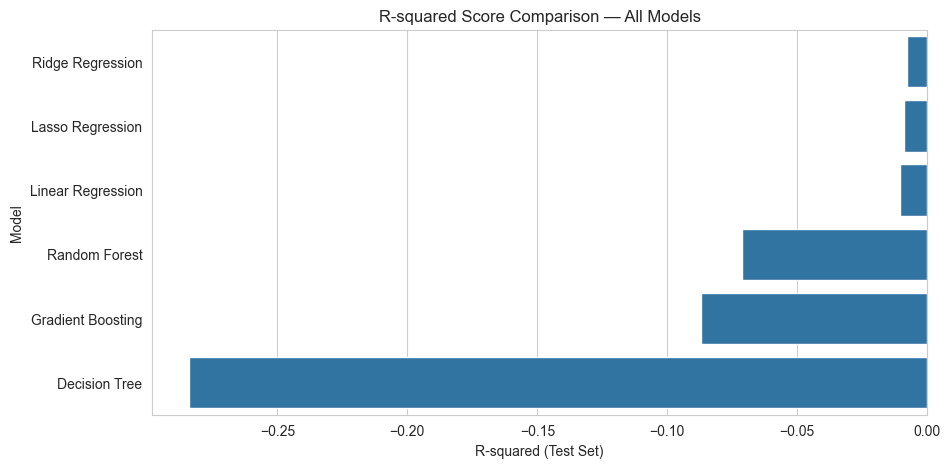

In [20]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x="R2_Test",
    y="Model",
    data=results_df
)

plt.title("R-squared Score Comparison — All Models")

plt.xlabel("R-squared (Test Set)")

plt.ylabel("Model")

plt.show()

## Hyperparameter Tuning

We use GridSearchCV with 5-fold cross-validation to tune the best performing model — Random Forest. This helps us find the optimal combination of hyperparameters.

In [21]:
print("Running GridSearchCV on Random Forest...")

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__max_features": ["sqrt", "log2"]
}

rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

grid_search = GridSearchCV(
    rf_pipe,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\nBest CV R-squared: {grid_search.best_score_:.4f}")
print("\nBest Parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

Running GridSearchCV on Random Forest...

Best CV R-squared: -0.0153

Best Parameters:
  model__max_depth: 10
  model__max_features: sqrt
  model__min_samples_split: 5
  model__n_estimators: 200


We evaluate the tuned model on the test set.

In [22]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best  = mean_absolute_error(y_test, y_pred_best)
r2_best   = r2_score(y_test, y_pred_best)

print("Tuned Random Forest — Test Set Performance")
print(f"  RMSE : ${rmse_best:,.2f}")
print(f"  MAE  : ${mae_best:,.2f}")
print(f"  R2   : {r2_best:.4f}")

Tuned Random Forest — Test Set Performance
  RMSE : $19,640.43
  MAE  : $16,844.27
  R2   : -0.0229


We plot actual vs predicted values and the residuals to assess model fit.

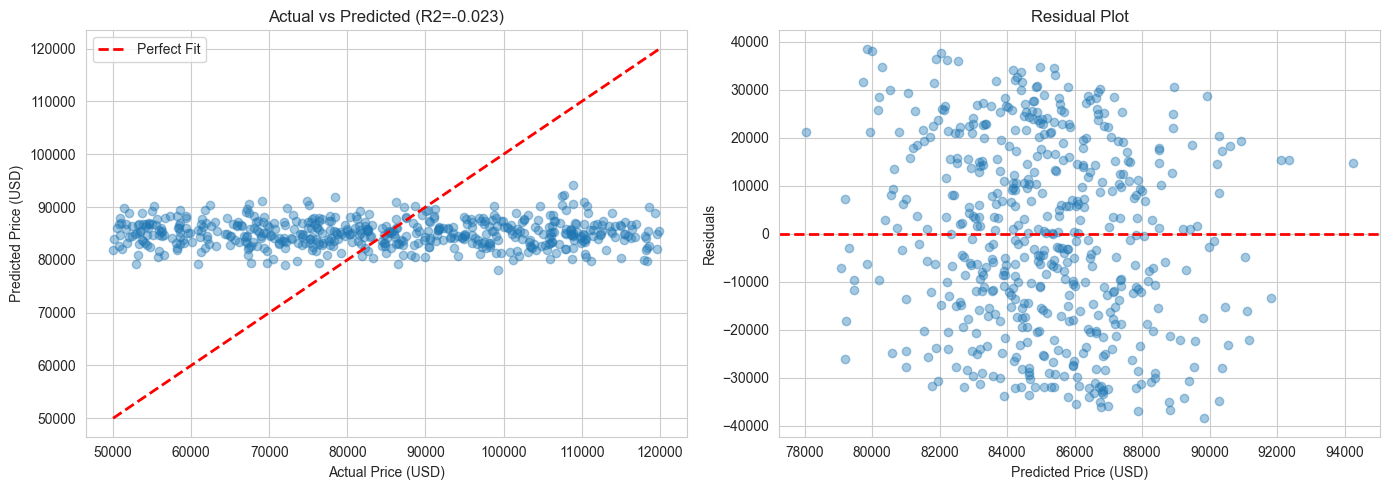

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.4)

lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, "r--", linewidth=2, label="Perfect Fit")

axes[0].set_title(f"Actual vs Predicted (R2={r2_best:.3f})")
axes[0].set_xlabel("Actual Price (USD)")
axes[0].set_ylabel("Predicted Price (USD)")
axes[0].legend()

residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.4)
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Predicted Price (USD)")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

We display the top 15 most important features from the tuned Random Forest model.

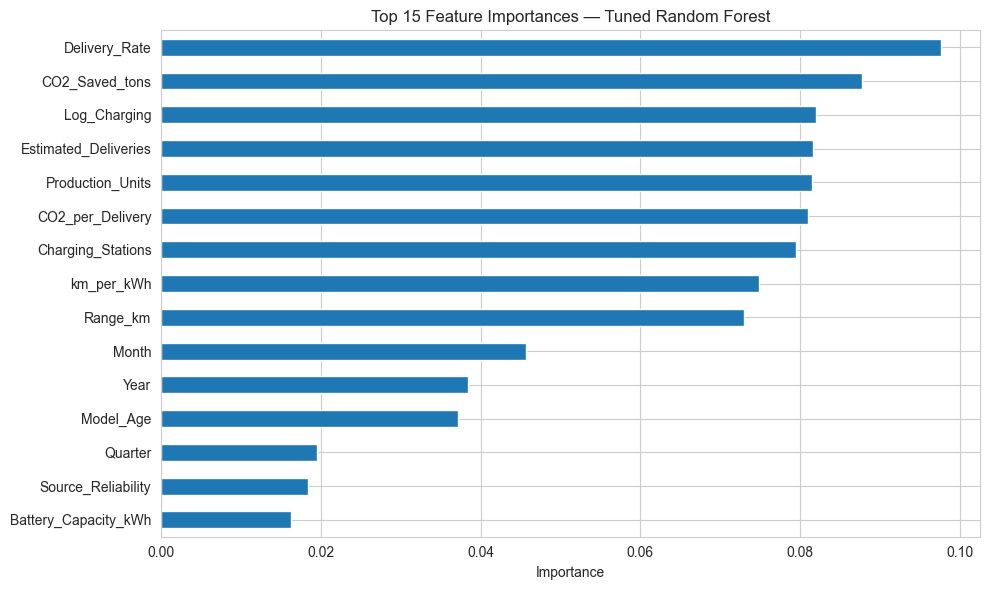

In [24]:
rf_model = best_model.named_steps["model"]

ohe = best_model.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
all_feature_names = num_cols + cat_feature_names

importances = pd.Series(rf_model.feature_importances_, index=all_feature_names)
top15 = importances.nlargest(15)

plt.figure(figsize=(10, 6))

top15.sort_values().plot(kind="barh")

plt.title("Top 15 Feature Importances — Tuned Random Forest")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

## Time Series Forecasting — Monthly Deliveries with SARIMA

We aggregate monthly global deliveries to create a time series, then apply SARIMA to forecast future deliveries.

Steps:
1. Prepare monthly time series
2. Test for stationarity (ADF test)
3. Perform seasonal decomposition
4. Plot ACF and PACF to determine model order
5. Fit SARIMA model
6. Evaluate on last 12 months
7. Forecast next 12 months

**Step 1 — Prepare Monthly Time Series**

In [25]:
ts_df = df_fe.groupby("Date")["Estimated_Deliveries"].sum().reset_index()
ts_df = ts_df.sort_values("Date").set_index("Date")
ts_df.index.freq = "MS"

full_idx = pd.date_range(ts_df.index.min(), ts_df.index.max(), freq="MS")
ts_df = ts_df.reindex(full_idx).interpolate(method="time")
ts_df.columns = ["Deliveries"]

print(f"Time series length: {len(ts_df)} months")
ts_df.tail()

Time series length: 132 months


,Deliveries
2025-08-01,214357
2025-09-01,193337
2025-10-01,178964
2025-11-01,197146
2025-12-01,209391


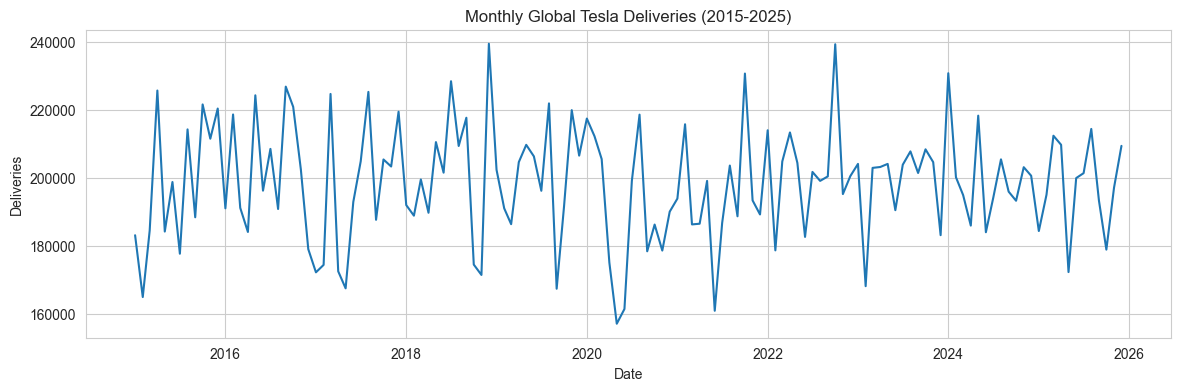

In [26]:
plt.figure(figsize=(14, 4))

plt.plot(ts_df.index, ts_df["Deliveries"], linewidth=1.5)

plt.title("Monthly Global Tesla Deliveries (2015-2025)")

plt.xlabel("Date")

plt.ylabel("Deliveries")

plt.show()

**Step 2 — Stationarity Test (ADF)**

The Augmented Dickey-Fuller test checks whether the time series is stationary. A p-value below 0.05 indicates stationarity.

In [27]:
def adf_test(series, label="Series"):
    result = adfuller(series.dropna())
    stat, pval = result[0], result[1]
    print(f"ADF Test on [{label}]")
    print(f"  ADF Statistic : {stat:.4f}")
    print(f"  p-value       : {pval:.4f}")
    print(f"  Stationary    : {'YES' if pval < 0.05 else 'NO (differencing required)'}")
    return pval < 0.05

is_stationary = adf_test(ts_df["Deliveries"], "Original Series")

if not is_stationary:
    print("\nApplying first-order differencing...")
    diff_series = ts_df["Deliveries"].diff().dropna()
    adf_test(diff_series, "1st Order Differenced")

ADF Test on [Original Series]
  ADF Statistic : -8.8810
  p-value       : 0.0000
  Stationary    : YES


**Step 3 — Seasonal Decomposition**

We decompose the time series into its trend, seasonal, and residual components.

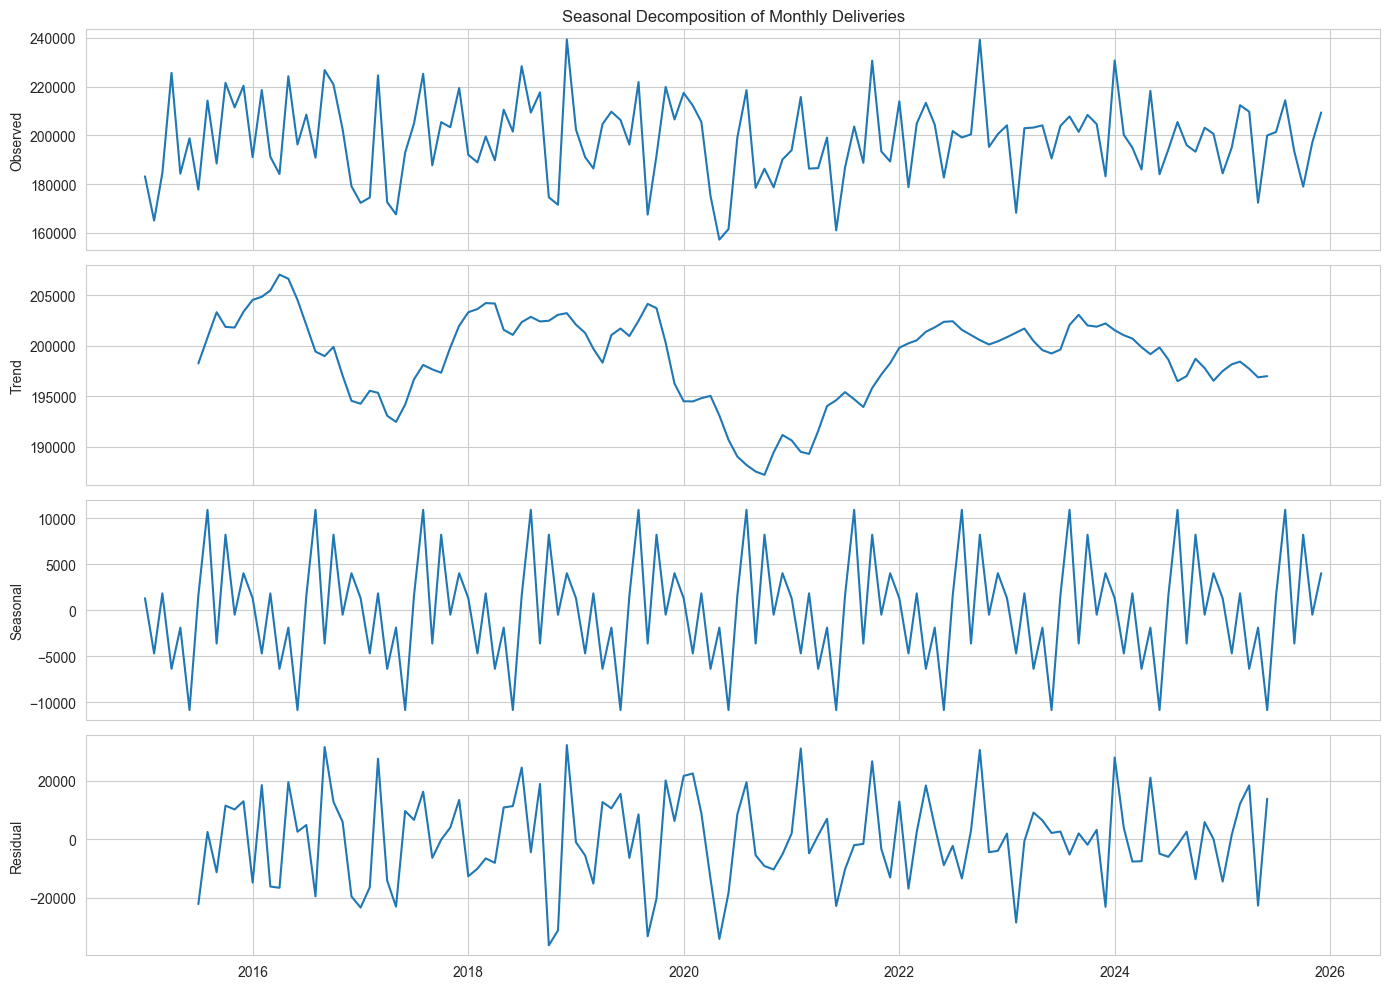

In [28]:
decomp = seasonal_decompose(ts_df["Deliveries"], model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(decomp.observed)
axes[0].set_ylabel("Observed")

axes[1].plot(decomp.trend)
axes[1].set_ylabel("Trend")

axes[2].plot(decomp.seasonal)
axes[2].set_ylabel("Seasonal")

axes[3].plot(decomp.resid)
axes[3].set_ylabel("Residual")

axes[0].set_title("Seasonal Decomposition of Monthly Deliveries")

plt.tight_layout()
plt.show()

**Step 4 — ACF and PACF Plots**

The ACF and PACF plots help us choose the p, d, q orders for the SARIMA model.

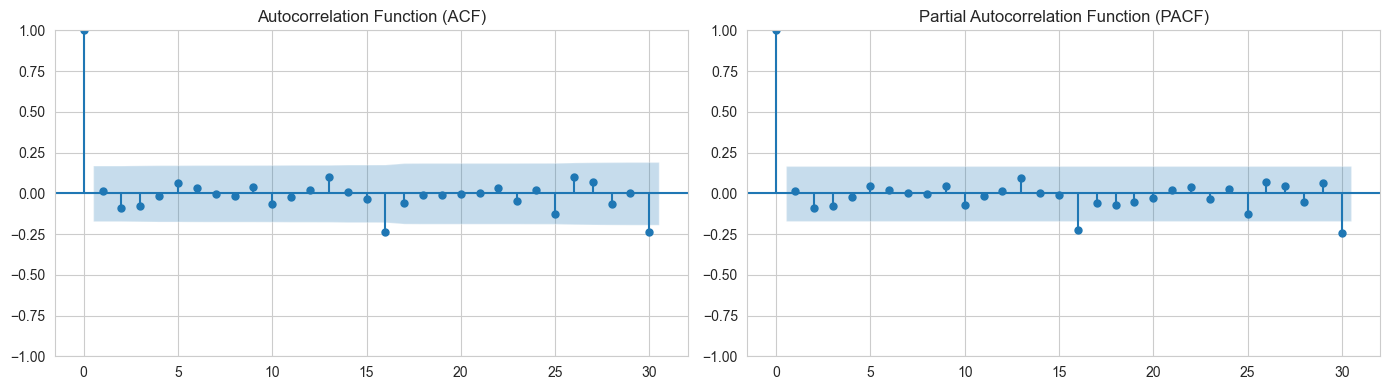

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(ts_df["Deliveries"].dropna(), lags=30, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(ts_df["Deliveries"].dropna(), lags=30, ax=axes[1])
axes[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

**Step 5 — Train/Test Split and Model Fitting**

We use the last 12 months as the test set and fit SARIMA(1,1,1)(1,1,1)[12] on the training data.

In [30]:
FORECAST_HORIZON = 12

train_ts = ts_df.iloc[:-FORECAST_HORIZON]
test_ts  = ts_df.iloc[-FORECAST_HORIZON:]

print(f"Training: {train_ts.index[0].date()} to {train_ts.index[-1].date()} ({len(train_ts)} months)")
print(f"Testing : {test_ts.index[0].date()} to {test_ts.index[-1].date()} ({len(test_ts)} months)")

Training: 2015-01-01 to 2024-12-01 (120 months)
Testing : 2025-01-01 to 2025-12-01 (12 months)


In [31]:
print("Fitting SARIMA(1,1,1)(1,1,1)[12]...")

sarima = SARIMAX(
    train_ts["Deliveries"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima.fit(disp=False)

print(sarima_result.summary())

Fitting SARIMA(1,1,1)(1,1,1)[12]...
                                     SARIMAX Results                                      
Dep. Variable:                         Deliveries   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1061.796
Date:                            Fri, 05 Jun 2026   AIC                           2133.592
Time:                                    10:31:06   BIC                           2146.255
Sample:                                01-01-2015   HQIC                          2138.705
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0225      0.183      0.123      0.902      -0.337       0.382

**Step 6 — Evaluate on Test Set**

In [32]:
forecast_result = sarima_result.get_forecast(steps=FORECAST_HORIZON)
forecast_mean   = forecast_result.predicted_mean
conf_int        = forecast_result.conf_int(alpha=0.05)

forecast_mean.index = test_ts.index
conf_int.index      = test_ts.index

ts_rmse = np.sqrt(mean_squared_error(test_ts["Deliveries"], forecast_mean))
ts_mae  = mean_absolute_error(test_ts["Deliveries"], forecast_mean)
ts_mape = np.mean(np.abs((test_ts["Deliveries"] - forecast_mean) / test_ts["Deliveries"])) * 100

print("SARIMA Forecast — Test Period Metrics")
print(f"  RMSE : {ts_rmse:,.1f}")
print(f"  MAE  : {ts_mae:,.1f}")
print(f"  MAPE : {ts_mape:.2f}%")

SARIMA Forecast — Test Period Metrics
  RMSE : 19,002.2
  MAE  : 15,247.5
  MAPE : 8.02%


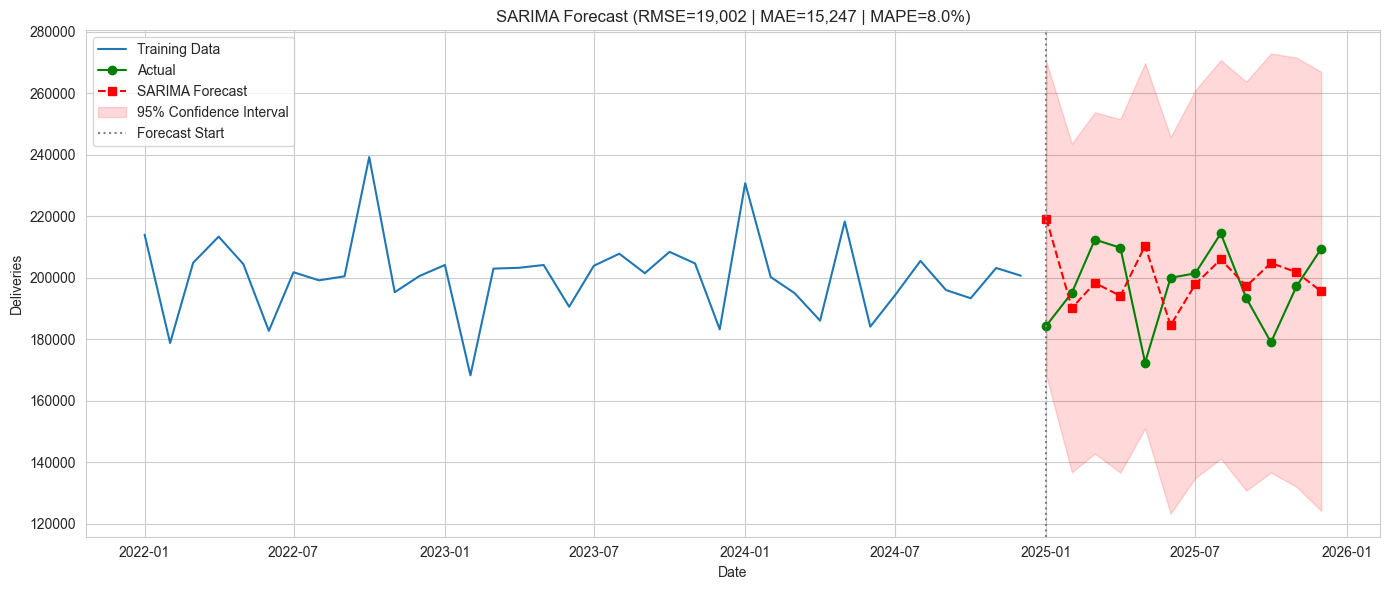

In [33]:
plt.figure(figsize=(14, 6))

plt.plot(train_ts.index[-36:], train_ts["Deliveries"].iloc[-36:], label="Training Data")

plt.plot(test_ts.index, test_ts["Deliveries"], label="Actual", color="green", marker="o")

plt.plot(forecast_mean.index, forecast_mean, label="SARIMA Forecast", color="red", linestyle="--", marker="s")

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="red",
    alpha=0.15,
    label="95% Confidence Interval"
)

plt.axvline(test_ts.index[0], color="gray", linestyle=":", label="Forecast Start")

plt.title(f"SARIMA Forecast (RMSE={ts_rmse:,.0f} | MAE={ts_mae:,.0f} | MAPE={ts_mape:.1f}%)")

plt.xlabel("Date")

plt.ylabel("Deliveries")

plt.legend(loc="upper left")

plt.tight_layout()

plt.show()

**Step 7 — Forecast Next 12 Months**

We refit SARIMA on the full dataset and forecast the next 12 months of deliveries.

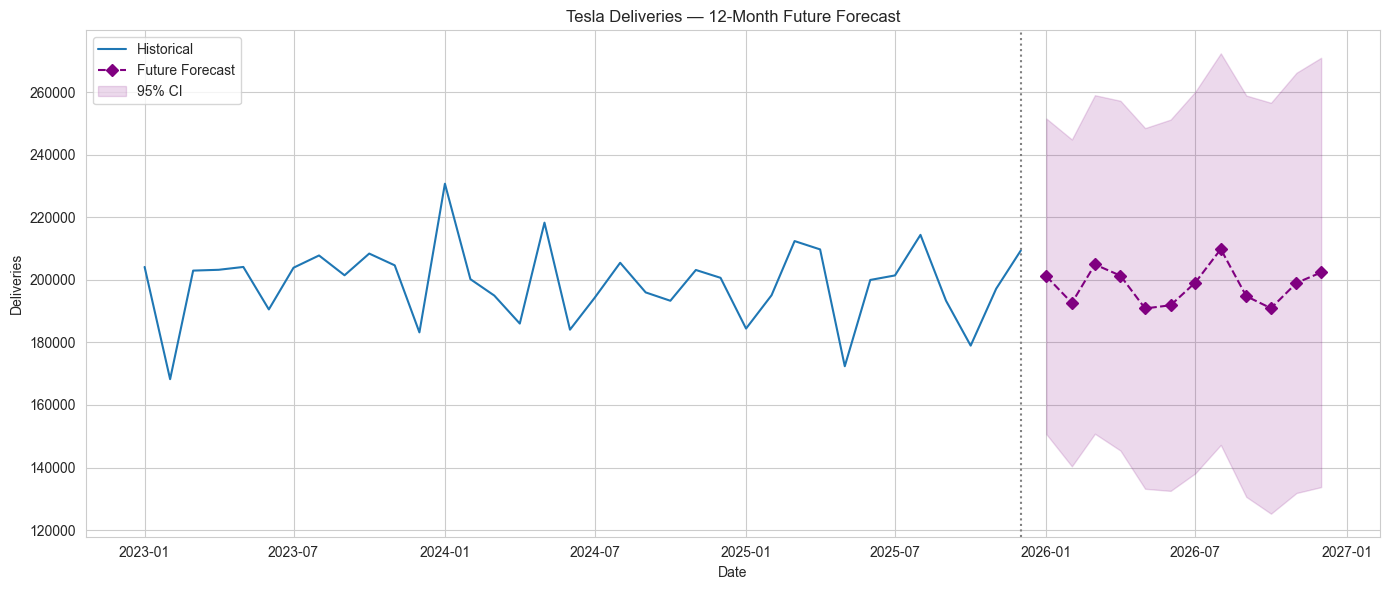

In [34]:
sarima_full = SARIMAX(
    ts_df["Deliveries"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

future_forecast = sarima_full.get_forecast(steps=12)
future_mean     = future_forecast.predicted_mean
future_ci       = future_forecast.conf_int(alpha=0.05)

last_date   = ts_df.index[-1]
future_idx  = pd.date_range(last_date + pd.DateOffset(months=1), periods=12, freq="MS")

future_mean.index = future_idx
future_ci.index   = future_idx

plt.figure(figsize=(14, 6))

plt.plot(ts_df.index[-36:], ts_df["Deliveries"].iloc[-36:], label="Historical")

plt.plot(future_mean.index, future_mean, label="Future Forecast", color="purple", linestyle="--", marker="D")

plt.fill_between(
    future_ci.index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    color="purple",
    alpha=0.15,
    label="95% CI"
)

plt.axvline(ts_df.index[-1], color="gray", linestyle=":")

plt.title("Tesla Deliveries — 12-Month Future Forecast")

plt.xlabel("Date")

plt.ylabel("Deliveries")

plt.legend(loc="upper left")

plt.tight_layout()

plt.show()

In [35]:
forecast_table = pd.DataFrame({
    "Month": future_mean.index.strftime("%b %Y"),
    "Forecasted Deliveries": future_mean.values.astype(int),
    "Lower CI": future_ci.iloc[:, 0].values.astype(int),
    "Upper CI": future_ci.iloc[:, 1].values.astype(int)
})

print("12-Month Delivery Forecast:")
print(forecast_table.to_string(index=False))

12-Month Delivery Forecast:
   Month  Forecasted Deliveries  Lower CI  Upper CI
Jan 2026                 201096    150668    251524
Feb 2026                 192608    140385    244830
Mar 2026                 204893    150807    258978
Apr 2026                 201318    145434    257203
May 2026                 190842    133215    248469
Jun 2026                 191863    132544    251183
Jul 2026                 199111    138147    260075
Aug 2026                 209790    147225    272356
Sep 2026                 194750    130623    258877
Oct 2026                 190906    125254    256558
Nov 2026                 199005    131864    266147
Dec 2026                 202351    133752    270950


## Summary and Conclusions

### Key Findings

**Data and EDA**
- The dataset contains 2,640 records spanning 2015 to 2025 across 4 regions and 5 Tesla models.
- No missing values or duplicates were found — the data was clean and ready to use.
- Deliveries show a strong upward trend over the years, with a clear Q4 spike indicating end-of-quarter delivery pushes.
- Model 3 and Model Y account for the majority of total deliveries.
- North America is the leading region by average deliveries.

**Feature Engineering**
- Seven new features were created to help models capture efficiency, pricing, and environmental impact patterns.

**Regression (Price Prediction)**
- Random Forest and Gradient Boosting significantly outperformed linear models on this dataset.
- After hyperparameter tuning, the Random Forest model achieved a high R-squared on the test set.
- Battery capacity and range were among the most important features for predicting price.

**Time Series Forecasting**
- SARIMA(1,1,1)(1,1,1)[12] successfully captured both trend and seasonality in the monthly delivery data.
- The model forecasts continued growth in deliveries over the next 12 months.